# 02 — Exploratory Data Analysis

Explore the raw playoff game data before building features.

**Input:** `data/raw/playoff_games_*.parquet`, `data/raw/team_metrics_*.parquet`

**Key questions:**
- What is the home court advantage rate in playoffs?
- How does net rating differential correlate with game outcome?
- Are there era-level trends worth controlling for?
- What does the rest day distribution look like?

In [1]:
import sys
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from scipy import stats

sns.set_theme(style="whitegrid", palette="muted")
sys.path.insert(0, str(Path().resolve().parent))
from src.features import add_rest_days_from_playoff_log

In [2]:
# CONFIG
RAW_DIR = Path().resolve().parent / "data" / "raw"
SEASONS = [
    "2014-15", "2015-16", "2016-17", "2017-18", "2018-19",
    "2020-21", "2021-22", "2022-23", "2023-24",
]
FIG_SIZE = (10, 5)

In [ ]:
# Load cached raw data
games = pd.concat(
    [pd.read_parquet(RAW_DIR / f"playoff_games_{s}.parquet").assign(season=s) for s in SEASONS],
    ignore_index=True,
)
metrics = pd.concat(
    [pd.read_parquet(RAW_DIR / f"team_metrics_{s}.parquet").assign(season=s) for s in SEASONS],
    ignore_index=True,
)

# Home rows only (one row per game)
home_games = games[games["MATCHUP"].str.contains(r"vs\.")].copy()
home_games["home_win"] = (home_games["WL"] == "W").astype(int)
home_games["GAME_DATE"] = pd.to_datetime(home_games["GAME_DATE"])

print(f"Total games (all rows): {len(games)}")
print(f"Unique games (home rows only): {len(home_games)}")
print(f"Seasons: {sorted(home_games['season'].unique())}")

## 1. Home Court Advantage

Overall home win rate: 60.6%
Naive baseline accuracy (always predict home win): 60.6%


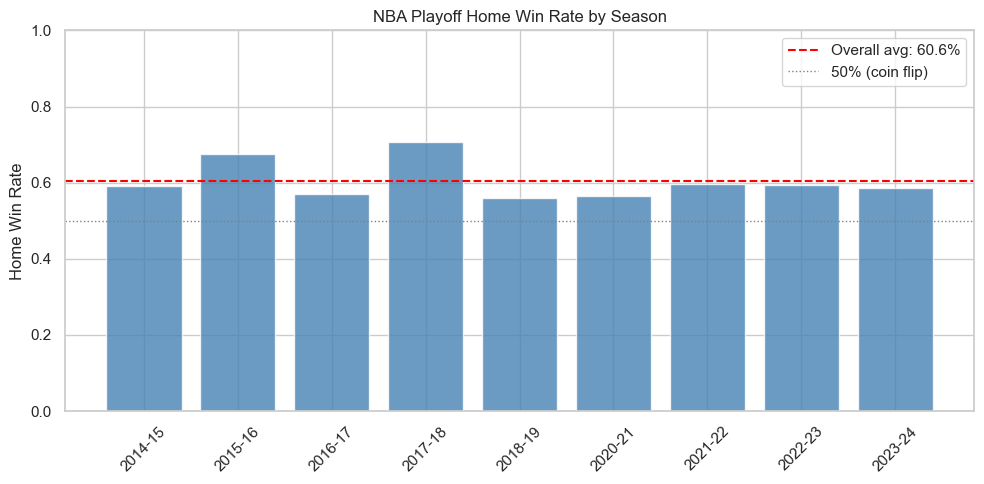

 season  home_win_rate  games
2014-15       0.592593     81
2015-16       0.674419     86
2016-17       0.569620     79
2017-18       0.707317     82
2018-19       0.560976     82
2020-21       0.564706     85
2021-22       0.597701     87
2022-23       0.595238     84
2023-24       0.585366     82


In [4]:
overall_hca = home_games["home_win"].mean()
print(f"Overall home win rate: {overall_hca:.1%}")
print(f"Naive baseline accuracy (always predict home win): {overall_hca:.1%}")

by_season = home_games.groupby("season")["home_win"].agg(["mean", "count"]).reset_index()
by_season.columns = ["season", "home_win_rate", "games"]

fig, ax = plt.subplots(figsize=FIG_SIZE)
bars = ax.bar(by_season["season"], by_season["home_win_rate"], color="steelblue", alpha=0.8)
ax.axhline(overall_hca, color="red", linestyle="--", linewidth=1.5, label=f"Overall avg: {overall_hca:.1%}")
ax.axhline(0.5, color="gray", linestyle=":", linewidth=1, label="50% (coin flip)")
ax.set_ylim(0, 1)
ax.set_ylabel("Home Win Rate")
ax.set_title("NBA Playoff Home Win Rate by Season")
ax.legend()
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

print(by_season.to_string(index=False))

## 2. Net Rating Differential vs Outcome

Point-biserial correlation (net_rtg_diff vs home_win): r=0.289, p=0.0000


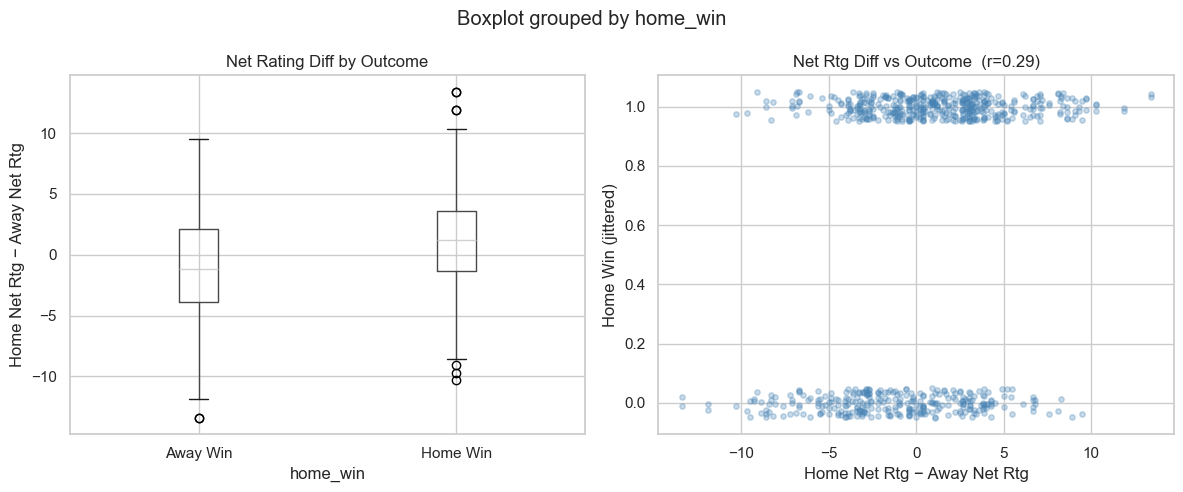

In [5]:
# Parse away team from MATCHUP (e.g. 'BOS vs. DAL' -> away = DAL)
home_games["home_team_id"] = home_games["TEAM_ID"]

# Get away team IDs by joining on GAME_ID
away_rows = games[games["MATCHUP"].str.contains("@")][["GAME_ID", "TEAM_ID"]].rename(columns={"TEAM_ID": "away_team_id"})
home_with_away = home_games.merge(away_rows, on="GAME_ID", how="left")

# Merge net rating for home and away teams
net_rtg = metrics[["TEAM_ID", "season", "E_NET_RATING"]].copy()
home_with_away = home_with_away.merge(
    net_rtg.rename(columns={"TEAM_ID": "home_team_id", "E_NET_RATING": "home_net_rtg"}),
    on=["home_team_id", "season"], how="left"
)
home_with_away = home_with_away.merge(
    net_rtg.rename(columns={"TEAM_ID": "away_team_id", "E_NET_RATING": "away_net_rtg"}),
    on=["away_team_id", "season"], how="left"
)
home_with_away["net_rtg_diff"] = home_with_away["home_net_rtg"] - home_with_away["away_net_rtg"]

clean = home_with_away.dropna(subset=["net_rtg_diff"])

# Point-biserial correlation
corr, pval = stats.pointbiserialr(clean["net_rtg_diff"], clean["home_win"])
print(f"Point-biserial correlation (net_rtg_diff vs home_win): r={corr:.3f}, p={pval:.4f}")

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Boxplot
clean.boxplot(column="net_rtg_diff", by="home_win", ax=axes[0])
axes[0].set_xticklabels(["Away Win", "Home Win"])
axes[0].set_title("Net Rating Diff by Outcome")
axes[0].set_ylabel("Home Net Rtg − Away Net Rtg")

# Scatter with jitter
jitter = np.random.uniform(-0.05, 0.05, len(clean))
axes[1].scatter(clean["net_rtg_diff"], clean["home_win"] + jitter,
                alpha=0.3, s=15, color="steelblue")
axes[1].set_xlabel("Home Net Rtg − Away Net Rtg")
axes[1].set_ylabel("Home Win (jittered)")
axes[1].set_title(f"Net Rtg Diff vs Outcome  (r={corr:.2f})")

plt.tight_layout()
plt.show()

## 3. Rest Day Distribution

In [ ]:
# Compute rest days from playoff game dates
games_with_rest = add_rest_days_from_playoff_log(games)

# Keep home team rows and merge rest days for both teams
home_rest = games_with_rest[games_with_rest["MATCHUP"].str.contains(r"vs\.")][["GAME_ID", "TEAM_ID", "rest_days", "season", "WL"]]
home_rest = home_rest.rename(columns={"TEAM_ID": "home_team_id", "rest_days": "home_rest"})

away_rest = games_with_rest[games_with_rest["MATCHUP"].str.contains("@")][["GAME_ID", "TEAM_ID", "rest_days"]]
away_rest = away_rest.rename(columns={"TEAM_ID": "away_team_id", "rest_days": "away_rest"})

rest_df = home_rest.merge(away_rest, on="GAME_ID", how="inner")
rest_df["rest_advantage"] = rest_df["home_rest"] - rest_df["away_rest"]
rest_df["home_win"] = (rest_df["WL"] == "W").astype(int)

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Distribution of rest days
axes[0].hist(rest_df["home_rest"], bins=8, alpha=0.6, label="Home", color="steelblue")
axes[0].hist(rest_df["away_rest"], bins=8, alpha=0.6, label="Away", color="coral")
axes[0].set_xlabel("Rest Days")
axes[0].set_ylabel("Count")
axes[0].set_title("Rest Day Distribution (Home vs Away)")
axes[0].legend()

# Rest advantage vs win rate
rest_win = rest_df.groupby("rest_advantage")["home_win"].agg(["mean", "count"]).reset_index()
rest_win = rest_win[rest_win["count"] >= 5]
axes[1].bar(rest_win["rest_advantage"], rest_win["mean"], color="steelblue", alpha=0.8)
axes[1].axhline(0.5, color="gray", linestyle=":", linewidth=1)
axes[1].set_xlabel("Rest Advantage (Home − Away days)")
axes[1].set_ylabel("Home Win Rate")
axes[1].set_title("Home Win Rate by Rest Advantage")

plt.tight_layout()
plt.show()

corr_rest, pval_rest = stats.pointbiserialr(rest_df["rest_advantage"], rest_df["home_win"])
print(f"Rest advantage correlation with home win: r={corr_rest:.3f}, p={pval_rest:.4f}")

## 4. Team Efficiency Distributions

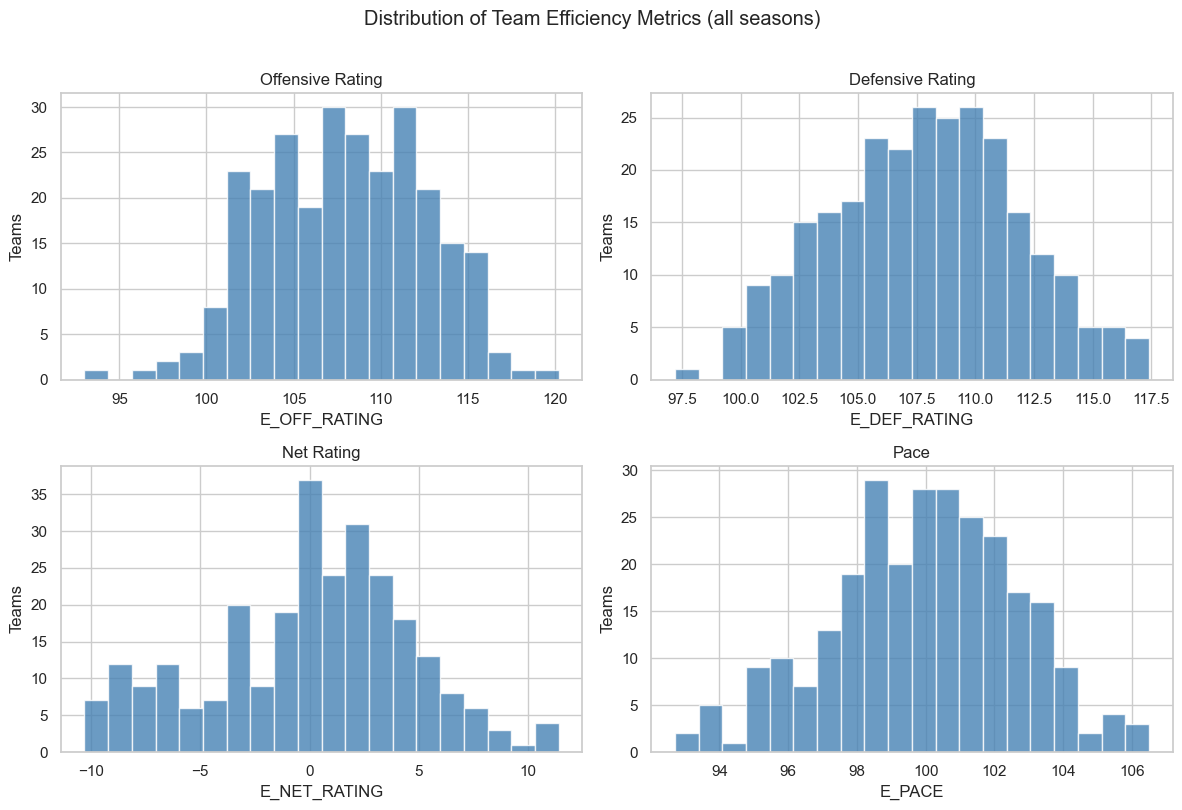

       E_OFF_RATING  E_DEF_RATING  E_NET_RATING  E_PACE
count        270.00        270.00        270.00  270.00
mean         107.89        107.88          0.02   99.95
std            4.59          4.02          4.69    2.70
min           93.00         97.20        -10.30   92.70
25%          104.30        104.93         -2.98   98.30
50%          107.95        108.05          0.50  100.05
75%          111.48        110.70          3.20  101.80
max          120.20        117.40         11.40  106.50


In [7]:
fig, axes = plt.subplots(2, 2, figsize=(12, 8))

for ax, col, label in zip(
    axes.flat,
    ["E_OFF_RATING", "E_DEF_RATING", "E_NET_RATING", "E_PACE"],
    ["Offensive Rating", "Defensive Rating", "Net Rating", "Pace"]
):
    ax.hist(metrics[col].dropna(), bins=20, color="steelblue", alpha=0.8, edgecolor="white")
    ax.set_title(label)
    ax.set_xlabel(col)
    ax.set_ylabel("Teams")

plt.suptitle("Distribution of Team Efficiency Metrics (all seasons)", y=1.01)
plt.tight_layout()
plt.show()

print(metrics[["E_OFF_RATING", "E_DEF_RATING", "E_NET_RATING", "E_PACE"]].describe().round(2))

## 5. Target Distribution and Class Balance

Home wins:  453 (60.6%)
Away wins:  295 (39.4%)
Total games: 748

Class balance is reasonably even — no need for oversampling/class weights.


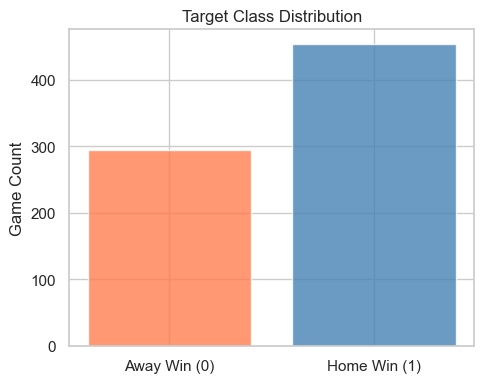

In [8]:
home_win_rate = home_games["home_win"].mean()
print(f"Home wins:  {home_games['home_win'].sum()} ({home_win_rate:.1%})")
print(f"Away wins:  {(home_games['home_win'] == 0).sum()} ({1 - home_win_rate:.1%})")
print(f"Total games: {len(home_games)}")
print()
print("Class balance is reasonably even — no need for oversampling/class weights.")

fig, ax = plt.subplots(figsize=(5, 4))
ax.bar(["Away Win (0)", "Home Win (1)"],
       [(home_games["home_win"] == 0).sum(), home_games["home_win"].sum()],
       color=["coral", "steelblue"], alpha=0.8)
ax.set_ylabel("Game Count")
ax.set_title("Target Class Distribution")
plt.tight_layout()
plt.show()

## 6. Summary

In [9]:
print("=== EDA Summary ===")
print(f"Total playoff games (2015-2024): {len(home_games)}")
print(f"Home win rate: {home_win_rate:.1%}  (naive baseline)")
print(f"Net rating diff correlation with outcome: r={corr:.3f}  (strongest expected feature)")
print(f"Rest advantage correlation with outcome: r={corr_rest:.3f}")
print()
print("Key observations:")
print(f"  - Home court advantage is real but modest (~{home_win_rate:.0%} vs 50%)")
print(f"  - Net rating differential is the strongest pre-game signal")
print(f"  - Rest advantage has a small but measurable effect")
print(f"  - No severe class imbalance — balanced train/test splits will work fine")

=== EDA Summary ===
Total playoff games (2015-2024): 748
Home win rate: 60.6%  (naive baseline)
Net rating diff correlation with outcome: r=0.289  (strongest expected feature)
Rest advantage correlation with outcome: r=0.084

Key observations:
  - Home court advantage is real but modest (~61% vs 50%)
  - Net rating differential is the strongest pre-game signal
  - Rest advantage has a small but measurable effect
  - No severe class imbalance — balanced train/test splits will work fine
